In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

In [2]:
base_dir = "../PetImages"
train_datagen = ImageDataGenerator(
    rescale=1/255.,
    validation_split=0.2
)
train_gen = train_datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

val_gen = train_datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


In [3]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 74, 74, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 72, 72, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 36, 36, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 34, 34, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 17, 17, 128)      0

In [4]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)


Epoch 1/10
352/625 [===============>..............] - ETA: 2:37 - loss: 0.6802 - accuracy: 0.5756

d:\sujal\dev\Machine learning projects\dog cat image recommendation\.venv\lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 [==============================] - 415s 663ms/step - loss: 0.6379 - accuracy: 0.6276 - val_loss: 0.5434 - val_accuracy: 0.7341
Epoch 2/10
625/625 [==============================] - 278s 445ms/step - loss: 0.4793 - accuracy: 0.7728 - val_loss: 0.4709 - val_accuracy: 0.7773
Epoch 3/10
625/625 [==============================] - 280s 448ms/step - loss: 0.3881 - accuracy: 0.8263 - val_loss: 0.4068 - val_accuracy: 0.8143
Epoch 4/10
625/625 [==============================] - 280s 448ms/step - loss: 0.2990 - accuracy: 0.8705 - val_loss: 0.4126 - val_accuracy: 0.8279
Epoch 5/10
625/625 [==============================] - 278s 445ms/step - loss: 0.1845 - accuracy: 0.9237 - val_loss: 0.4388 - val_accuracy: 0.8339
Epoch 6/10
625/625 [==============================] - 281s 449ms/step - loss: 0.0979 - accuracy: 0.9625 - val_loss: 0.5645 - val_accuracy: 0.8299
Epoch 7/10
625/625 [==============================] - 281s 450ms/step - loss: 0.0518 - accuracy: 0.9833 - val_loss: 0.6989 - val_accura

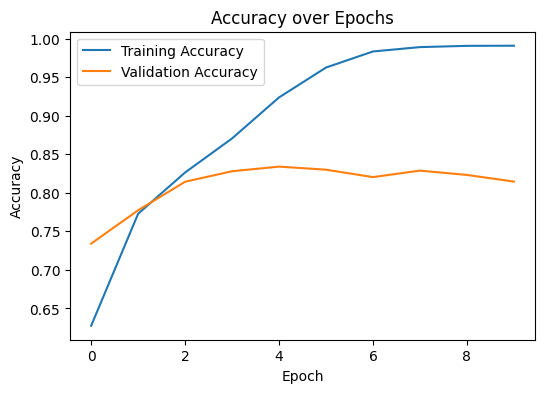

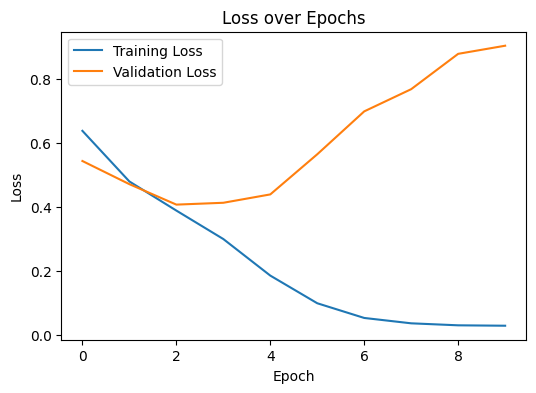

In [5]:
import matplotlib.pyplot as plt

# Accuracy graphs
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss graphs
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


1/1 [==============================] - 0s 20ms/step
Prediction: DOG 🐶
Raw prediction value: 0.9999813


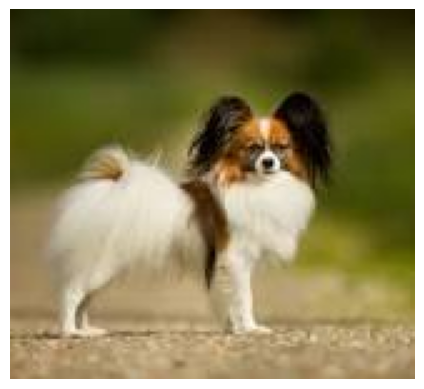

In [7]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Path to the image you want to test
img_path = "image.png"   # change to your image name

# Load and preprocess
img = image.load_img(img_path, target_size=(150,150))
img_arr = image.img_to_array(img) / 255.0
img_arr = np.expand_dims(img_arr, axis=0)

# Predict
prediction = model.predict(img_arr)[0][0]

# Show image
plt.imshow(image.load_img(img_path))
plt.axis('off')

# Output result
if prediction > 0.5:
    print("Prediction: DOG 🐶")
else:
    print("Prediction: CAT 🐱")

print("Raw prediction value:", prediction)
